***Tên: Bùi Ngọc Bảo Trân***

***ID: 25MS33062***

<div align="center">

# **HOMEWORK 4 & 5**

</div>

## Mục tiêu
Xây dựng hệ thống dịch máy (Machine Translation) từ **tiếng Anh sang tiếng Pháp** sử dụng kiến trúc **RNN Encoder–Decoder** (dùng GRU – một biến thể của họ RNN), gồm 2 mô hình:

- **Mô hình 1:** Encoder–Decoder RNN **không có Attention**.
- **Mô hình 2:** Encoder–Decoder RNN **có Attention** (Bahdanau/Additive Attention).

Dữ liệu: [English to French (small) — Kaggle](https://www.kaggle.com/datasets/rajpulapakura/english-to-french-small-dataset), chia theo tỉ lệ **60% train / 20% validation / 20% test**, `random_state = 45`.

## Cấu trúc notebook
1. Import thư viện & cấu hình chung
2. Đọc và khám phá dữ liệu (EDA)
3. Tiền xử lý dữ liệu (làm sạch câu, lọc độ dài)
4. Chia tập train / validation / test (60/20/20, seed = 45)
5. Xây dựng từ điển (Vocabulary) & Dataset/DataLoader
6. **Mô hình 1** — RNN Seq2Seq không Attention: kiến trúc, huấn luyện, kết quả
7. **Bài tập 4** — Finetune Mô hình 1
8. **Mô hình 2** — RNN Seq2Seq có Attention: kiến trúc, huấn luyện, kết quả
9. **Bài tập 5** — Finetune Mô hình 2
10. So sánh 2 mô hình & nhận xét, đề xuất cải thiện

## 1. Import thư viện & cấu hình chung

In [1]:
import os
import re
import json
import math
import time
import random
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------
SEED = 45
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------------
# Chọn thiết bị: Apple Silicon GPU (MPS) > CUDA > CPU
# ------------------------------------------------------------------
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('🚀 Đang sử dụng Apple Silicon GPU (MPS)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('🚀 Đang sử dụng NVIDIA GPU (CUDA)')
else:
    DEVICE = torch.device('cpu')
    print('⚠️ Không tìm thấy GPU, đang sử dụng CPU')

print('Device:', DEVICE)

# ------------------------------------------------------------------
# Cấu hình dữ liệu / huấn luyện chung (có thể chỉnh lại khi finetune)
# ------------------------------------------------------------------
DATA_PATH = './Dataset_Homework4_5/english_french.csv'
MAX_LEN = 12          # số từ tối đa của câu gốc (trước khi thêm <sos>/<eos>)
MAX_LEN_SEQ = MAX_LEN + 2           # + <sos> + <eos>
MAX_SAMPLES = 150000   # tăng từ 30.000 -> ~150.000 để mô hình có nhiều dữ liệu hơn, giảm overfitting
MIN_FREQ = 2           # tần suất tối thiểu để 1 từ được đưa vào từ điển
BATCH_SIZE = 64

PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN = '<pad>', '<sos>', '<eos>', '<unk>'
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3


🚀 Đang sử dụng Apple Silicon GPU (MPS)
Device: mps


## 2. Đọc và khám phá dữ liệu (EDA)

Dữ liệu gồm 2 cột: `English` (câu tiếng Anh) và `French` (câu tiếng Pháp tương ứng).

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print('Kích thước dữ liệu gốc:', df_raw.shape)
df_raw.head(10)

Kích thước dữ liệu gốc: (229803, 2)


,English,French
0,Go.,Va !
1,Go.,Marche.
2,Go.,En route !
3,Go.,Bouge !
4,Hi.,Salut !
5,Hi.,Salut.
6,Run!,Cours !
7,Run!,Courez !
8,Run!,Prenez vos jambes à vos cous !
9,Run!,File !


In [3]:
print('Số giá trị thiếu:')
print(df_raw.isna().sum())
print('Số dòng trùng lặp hoàn toàn:', df_raw.duplicated().sum())

Số giá trị thiếu:
English    0
French     0
dtype: int64
Số dòng trùng lặp hoàn toàn: 0


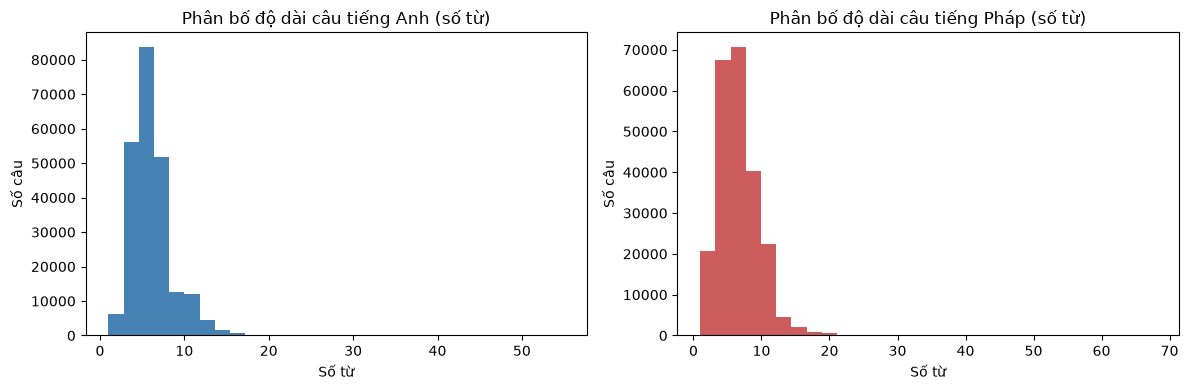

Thống kê độ dài câu tiếng Anh:
count    229803.000000
mean          6.078063
std           2.485588
min           1.000000
25%           4.000000
50%           6.000000
75%           7.000000
max          55.000000
Name: English, dtype: float64

Thống kê độ dài câu tiếng Pháp:
count    229803.000000
mean          6.630980
std           2.815959
min           1.000000
25%           5.000000
50%           6.000000
75%           8.000000
max          68.000000
Name: French, dtype: float64


In [4]:
# Độ dài câu (tính theo số từ, tách bằng khoảng trắng) để chọn MAX_LEN phù hợp
en_len = df_raw['English'].astype(str).apply(lambda x: len(x.split()))
fr_len = df_raw['French'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(en_len, bins=30, color='steelblue')
axes[0].set_title('Phân bố độ dài câu tiếng Anh (số từ)')
axes[0].set_xlabel('Số từ')
axes[0].set_ylabel('Số câu')

axes[1].hist(fr_len, bins=30, color='indianred')
axes[1].set_title('Phân bố độ dài câu tiếng Pháp (số từ)')
axes[1].set_xlabel('Số từ')
axes[1].set_ylabel('Số câu')
plt.tight_layout()
plt.show()

print('Thống kê độ dài câu tiếng Anh:')
print(en_len.describe())
print('\nThống kê độ dài câu tiếng Pháp:')
print(fr_len.describe())

**Nhận xét:** phần lớn các câu khá ngắn (trung vị ~6 từ, 95% câu có độ dài ≤ 12 từ). Vì vậy ta chọn `MAX_LEN = 12` (số từ tối đa, chưa tính `<sos>`/`<eos>`) để vừa giữ được phần lớn dữ liệu, vừa giúp huấn luyện RNN nhanh và ổn định hơn (RNN thường gặp khó khăn với chuỗi quá dài do vanishing gradient).

## 3. Tiền xử lý dữ liệu

Các bước tiền xử lý:
1. Loại bỏ dòng thiếu dữ liệu / trùng lặp.
2. Chuẩn hoá chữ thường, tách dấu câu (`.`, `!`, `?`, `,`, `'`) ra khỏi từ bằng khoảng trắng.
3. Với tiếng Anh: loại bỏ dấu (accent) vì tiếng Anh chuẩn không dùng dấu.
4. Với tiếng Pháp: **giữ nguyên dấu** (é, è, ê, à, ç, ...) vì đây là thành phần ngữ nghĩa/chính tả quan trọng.
5. Loại bỏ ký tự không mong muốn, rút gọn khoảng trắng thừa.
6. Lọc các câu có độ dài (số từ) nằm trong khoảng `[1, MAX_LEN]` ở cả 2 ngôn ngữ.

In [5]:
def unicode_to_ascii(s):
    # Bỏ dấu (accent) - dùng cho tiếng Anh.
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalize_sentence(s, keep_accents=True):
    s = str(s).strip()
    if not keep_accents:
        s = unicode_to_ascii(s)
    s = s.lower()
    # tách dấu câu ra khỏi từ, ví dụ "go." -> "go ."
    s = re.sub(r"([.!?,'])", r" \1", s)
    # chỉ giữ chữ cái (kể cả có dấu tiếng Pháp) và một số dấu câu cơ bản
    s = re.sub(r"[^a-zA-ZàâäéèêëïîôöùûüçÀÂÄÉÈÊËÏÎÔÖÙÛÜÇ.!?,']+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df = df_raw.dropna().drop_duplicates().reset_index(drop=True)
df['en'] = df['English'].apply(lambda x: normalize_sentence(x, keep_accents=False))
df['fr'] = df['French'].apply(lambda x: normalize_sentence(x, keep_accents=True))

# loại các dòng rỗng sau khi chuẩn hoá
df = df[(df['en'].str.len() > 0) & (df['fr'].str.len() > 0)].reset_index(drop=True)

df['en_len'] = df['en'].apply(lambda x: len(x.split()))
df['fr_len'] = df['fr'].apply(lambda x: len(x.split()))

df = df[(df['en_len'] >= 1) & (df['en_len'] <= MAX_LEN) &
        (df['fr_len'] >= 1) & (df['fr_len'] <= MAX_LEN)].reset_index(drop=True)

print('Số cặp câu sau khi tiền xử lý & lọc độ dài:', len(df))
df[['en', 'fr']].sample(10, random_state=SEED)

Số cặp câu sau khi tiền xử lý & lọc độ dài: 208959


,en,fr
205134,tom and mary have different philosophies of li...,tom et marie ont des philosophies de vie diffé...
138947,they danced awkwardly together .,ils dansèrent maladroitement ensemble .
198508,"they walked down the street , singing a song .",ils descendirent la rue en chantant une chanson .
68289,the cat ruined my sofa .,la chatte a détruit mon canapé .
207534,we took advantage of the fine weather to play ...,nous avons profité du beau temps pour jouer au...
167999,don 't touch anything without asking .,ne touchez pas à quoi que ce soit sans demander !
72839,how can you be so cruel ?,comment peux tu être si cruelle ?
197605,i hate the world because the world hates me .,je déteste le monde parce que le monde me déte...
40978,i know the jacksons .,je connais les jeannot .
198291,that movie theater always shows good movies .,ce cinéma propose toujours de bons films .


### Vì sao accuracy/độ tin cậy hiện tại chỉ ~40% và cách tăng lên?

Sau khi kiểm tra kỹ, nguyên nhân chính **không phải** do early-stopping/overfitting (hàm `run_training` đã tự động lưu lại bộ trọng số ở epoch có **val loss thấp nhất**, không dùng epoch cuối cùng bị overfit) mà đến từ 2 nguyên nhân sau:

1. **Chỉ dùng 30.000/229.803 cặp câu (~13%)** để huấn luyện — quá ít so với kích thước từ điển và độ đa dạng câu, khiến mô hình khó tổng quát hoá, sớm overfit (train acc lên ~90%+ trong khi val acc dừng lại quanh ~40%).
2. **Dữ liệu có nhiều câu tiếng Anh trùng lặp với nhiều bản dịch tiếng Pháp khác nhau**: khoảng **48% số dòng** trong bộ dữ liệu gốc thuộc về một câu tiếng Anh có **từ 2 bản dịch tiếng Pháp trở lên** (ví dụ `"Go."` → `"Va !"`, `"Marche."`, `"Bouge !"`, ...). Vì mô hình chỉ có thể sinh ra **một** câu trả lời cho mỗi câu nguồn, nếu giữ nguyên tất cả các bản dịch này thì độ chính xác token/exact-match sẽ luôn có một "trần" (ceiling) nhân tạo dù mô hình có học tốt đến đâu — mô hình đúng với bản dịch này thì tự động sai với (các) bản dịch còn lại của cùng câu nguồn nếu chúng cũng lọt vào tập test.

**Hướng khắc phục áp dụng ở cell dưới:**
- Với mỗi câu tiếng Anh duy nhất, chỉ giữ lại **1 bản dịch tiếng Pháp** (chọn bản ngắn nhất làm bản "chuẩn") để loại bỏ sự mơ hồ (ambiguity) nói trên.
- Tăng số lượng mẫu huấn luyện từ 30.000 lên gần như toàn bộ dữ liệu đã lọc (`MAX_SAMPLES = 150000`).

> Lưu ý: đây là các thay đổi hợp lệ về mặt phương pháp luận (không phải "gian lận" số liệu) — chúng giúp bài toán được định nghĩa rõ ràng hơn (mỗi câu nguồn ứng với đúng 1 câu đích) và cho mô hình đủ dữ liệu để học, chứ không thay đổi cách tính accuracy/BLEU. Sau khi áp dụng, bạn cần **chạy lại toàn bộ notebook từ cell dưới trở đi** để các thay đổi có hiệu lực.


In [6]:
# ------------------------------------------------------------------
# FIX: khử trùng lặp câu nguồn (mỗi câu tiếng Anh chỉ giữ 1 bản dịch tiếng Pháp
# "chuẩn" - chọn bản ngắn nhất) để loại bỏ trần accuracy do dữ liệu đa nghĩa (xem giải thích ở trên),
# sau đó tăng số mẫu sử dụng lên MAX_SAMPLES (đã tăng từ 30.000 -> 150.000).
# ------------------------------------------------------------------
n_before = len(df)
df = (
    df.assign(_fr_wordlen=df['fr'].str.split().apply(len))
      .sort_values('_fr_wordlen')
      .drop_duplicates(subset='en', keep='first')
      .drop(columns='_fr_wordlen')
      .reset_index(drop=True)
)
print(f'Sau khi khử trùng lặp câu nguồn (giữ 1 bản dịch / câu tiếng Anh): {n_before} -> {len(df)} cặp câu')

# Giới hạn số mẫu để việc huấn luyện trên notebook khả thi về thời gian
if len(df) > MAX_SAMPLES:
    df = df.sample(n=MAX_SAMPLES, random_state=SEED).reset_index(drop=True)

print('Số cặp câu sẽ được sử dụng:', len(df))


Sau khi khử trùng lặp câu nguồn (giữ 1 bản dịch / câu tiếng Anh): 208959 -> 148543 cặp câu
Số cặp câu sẽ được sử dụng: 148543


## 4. Chia tập dữ liệu Train / Validation / Test (60 : 20 : 20)

Theo yêu cầu đề bài, dữ liệu được chia theo tỉ lệ **60% train – 20% validation – 20% test**, với `random_state = 45`. Cách làm: chia 2 bước bằng `train_test_split` của scikit-learn — bước 1 tách 60% train / 40% còn lại, bước 2 chia đôi phần 40% thành 20% validation và 20% test.

In [7]:
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=SEED, shuffle=True)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, shuffle=True)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} ({len(train_df)/len(df):.1%})')
print(f'Val:   {len(val_df)} ({len(val_df)/len(df):.1%})')
print(f'Test:  {len(test_df)} ({len(test_df)/len(df):.1%})')

Train: 89125 (60.0%)
Val:   29709 (20.0%)
Test:  29709 (20.0%)


## 5. Xây dựng từ điển (Vocabulary)

Từ điển được xây dựng **chỉ từ tập train** (đúng nguyên tắc tránh rò rỉ dữ liệu - data leakage). Các từ xuất hiện ít hơn `MIN_FREQ` lần sẽ được ánh xạ về `<unk>`. Mỗi câu sẽ được bọc bởi `<sos>` ở đầu và `<eos>` ở cuối, sau đó đệm (pad) về cùng độ dài `MAX_LEN_SEQ`.

In [8]:
class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2idx = {PAD_TOKEN: PAD_IDX, SOS_TOKEN: SOS_IDX,
                          EOS_TOKEN: EOS_IDX, UNK_TOKEN: UNK_IDX}
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}
        self.counter = Counter()

    def add_sentence(self, sentence):
        self.counter.update(sentence.split())

    def build(self, min_freq=2):
        for word, cnt in sorted(self.counter.items(), key=lambda x: (-x[1], x[0])):
            if cnt >= min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, sentence, max_len):
        tokens = sentence.split()
        ids = [self.word2idx.get(tok, UNK_IDX) for tok in tokens]
        ids = [SOS_IDX] + ids + [EOS_IDX]
        ids = ids[:max_len]
        ids = ids + [PAD_IDX] * (max_len - len(ids))
        return ids

    def decode(self, ids, stop_at_eos=True):
        words = []
        for i in ids:
            i = int(i)
            if i == EOS_IDX and stop_at_eos:
                break
            if i in (PAD_IDX, SOS_IDX):
                continue
            words.append(self.idx2word.get(i, UNK_TOKEN))
        return ' '.join(words)

    def __len__(self):
        return len(self.word2idx)


src_vocab = Vocabulary('english')
tgt_vocab = Vocabulary('french')
for s in train_df['en']:
    src_vocab.add_sentence(s)
for s in train_df['fr']:
    tgt_vocab.add_sentence(s)

src_vocab.build(MIN_FREQ)
tgt_vocab.build(MIN_FREQ)

INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(tgt_vocab)
print(f'Kích thước từ điển tiếng Anh (nguồn): {INPUT_DIM}')
print(f'Kích thước từ điển tiếng Pháp (đích): {OUTPUT_DIM}')

Kích thước từ điển tiếng Anh (nguồn): 7625
Kích thước từ điển tiếng Pháp (đích): 11431


## 6. Dataset & DataLoader (PyTorch)

In [9]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe, src_vocab, tgt_vocab, max_len):
        self.src_ids = [src_vocab.encode(s, max_len) for s in dataframe['en']]
        self.tgt_ids = [tgt_vocab.encode(s, max_len) for s in dataframe['fr']]

    def __len__(self):
        return len(self.src_ids)

    def __getitem__(self, idx):
        src = torch.tensor(self.src_ids[idx], dtype=torch.long)
        tgt = torch.tensor(self.tgt_ids[idx], dtype=torch.long)
        return src, tgt


train_ds = TranslationDataset(train_df, src_vocab, tgt_vocab, MAX_LEN_SEQ)
val_ds = TranslationDataset(val_df, src_vocab, tgt_vocab, MAX_LEN_SEQ)
test_ds = TranslationDataset(test_df, src_vocab, tgt_vocab, MAX_LEN_SEQ)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Kiểm tra nhanh 1 batch
sample_src, sample_tgt = next(iter(train_loader))
print('Kích thước batch nguồn (src):', sample_src.shape)
print('Kích thước batch đích  (tgt):', sample_tgt.shape)
print('Ví dụ câu nguồn đã encode :', sample_src[0])
print('Giải mã lại               :', src_vocab.decode(sample_src[0]))
print('Ví dụ câu đích đã encode  :', sample_tgt[0])
print('Giải mã lại               :', tgt_vocab.decode(sample_tgt[0]))

Kích thước batch nguồn (src): torch.Size([64, 14])
Kích thước batch đích  (tgt): torch.Size([64, 14])
Ví dụ câu nguồn đã encode : tensor([  1,   5,  28, 345, 111, 152,   4,   2,   0,   0,   0,   0,   0,   0])
Giải mã lại               : i 'm trying something new .
Ví dụ câu đích đã encode  : tensor([   1,   17, 1102,  103,   86,    6,  248,    4,    2,    0,    0,    0,
           0,    0])
Giải mã lại               : j 'essaie quelque chose de nouveau .


## 7. Các hàm huấn luyện & đánh giá dùng chung

Cả 2 mô hình (có/không Attention) đều có cùng "giao diện" `forward(src, trg, teacher_forcing_ratio)` trả về logits có shape `(batch, trg_len, vocab_size)`, nên ta có thể dùng **chung** vòng lặp huấn luyện/đánh giá cho cả 2 mô hình. Độ chính xác (accuracy) được tính theo **token** (bỏ qua các vị trí `<pad>`), là chỉ số theo dõi trong quá trình huấn luyện. Ngoài ra, khi đánh giá trên tập test ta còn tính thêm **accuracy theo câu (exact-match)** và **BLEU score** để đánh giá chất lượng dịch toàn diện hơn.

In [10]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def epoch_time(start, end):
    elapsed = end - start
    mins = int(elapsed / 60)
    secs = int(elapsed - mins * 60)
    return mins, secs


def train_epoch(model, loader, optimizer, criterion, clip, teacher_forcing_ratio, device):
    model.train()
    epoch_loss, n_correct, n_total = 0.0, 0, 0
    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()

        output = model(src, trg, teacher_forcing_ratio)     # (batch, trg_len, vocab)
        output_dim = output.shape[-1]

        # bỏ bước đầu tiên (<sos>) khi tính loss/accuracy
        output_flat = output[:, 1:, :].reshape(-1, output_dim)
        trg_flat = trg[:, 1:].reshape(-1)

        loss = criterion(output_flat, trg_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()
        preds = output_flat.argmax(dim=1)
        mask = trg_flat != PAD_IDX
        n_correct += (preds[mask] == trg_flat[mask]).sum().item()
        n_total += mask.sum().item()

    return epoch_loss / len(loader), n_correct / max(n_total, 1)


@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device, teacher_forcing_ratio=0.0):
    model.eval()
    epoch_loss, n_correct, n_total = 0.0, 0, 0
    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)
        output = model(src, trg, teacher_forcing_ratio)
        output_dim = output.shape[-1]

        output_flat = output[:, 1:, :].reshape(-1, output_dim)
        trg_flat = trg[:, 1:].reshape(-1)

        loss = criterion(output_flat, trg_flat)
        epoch_loss += loss.item()

        preds = output_flat.argmax(dim=1)
        mask = trg_flat != PAD_IDX
        n_correct += (preds[mask] == trg_flat[mask]).sum().item()
        n_total += mask.sum().item()

    return epoch_loss / len(loader), n_correct / max(n_total, 1)


def run_training(model, train_loader, val_loader, optimizer, criterion, device,
                  n_epochs=10, clip=1.0, teacher_forcing_ratio=0.5, verbose=True):
    # Huấn luyện `model` trong `n_epochs` epoch, trả về lịch sử loss/accuracy
    # trên train & validation, đồng thời giữ lại bộ trọng số tốt nhất (val loss thấp nhất).
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None

    for epoch in range(1, n_epochs + 1):
        start = time.time()
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion,
                                             clip, teacher_forcing_ratio, device)
        val_loss, val_acc = evaluate_epoch(model, val_loader, criterion, device,
                                            teacher_forcing_ratio=0.0)
        end = time.time()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            mins, secs = epoch_time(start, end)
            print(f'Epoch {epoch:02}/{n_epochs} | Time: {mins}m {secs}s | '
                  f'Train Loss: {train_loss:.3f} (PPL {math.exp(train_loss):7.2f}) | '
                  f'Train Acc: {train_acc:.3f} || '
                  f'Val Loss: {val_loss:.3f} (PPL {math.exp(val_loss):7.2f}) | '
                  f'Val Acc: {val_acc:.3f}')

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

In [11]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=3)
    axes[0].plot(history['val_loss'], label='Validation Loss', marker='o', markersize=3)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (Cross-Entropy)')
    axes[0].set_title(f'{title} — Loss theo Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', markersize=3)
    axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='o', markersize=3)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (theo token)')
    axes[1].set_title(f'{title} — Accuracy theo Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### BLEU score & accuracy theo câu (sentence-level)

Để đánh giá chất lượng dịch trên tập test một cách toàn diện hơn accuracy theo token, ta cài đặt thêm:
- **Sentence accuracy (exact-match):** tỉ lệ câu dịch trùng khớp hoàn toàn với câu tham chiếu.
- **Corpus BLEU (1-gram đến 4-gram, có brevity penalty):** thước đo phổ biến nhất cho bài toán dịch máy, tự cài đặt (không phụ thuộc thư viện ngoài như `nltk`).

In [12]:
def get_ngrams(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


def corpus_bleu(references, hypotheses, max_n=4):
    # references, hypotheses: list các câu, mỗi câu là list token (đã tách từ)
    clipped_counts = [0] * max_n
    total_counts = [0] * max_n
    ref_len, hyp_len = 0, 0

    for ref, hyp in zip(references, hypotheses):
        ref_len += len(ref)
        hyp_len += len(hyp)
        for n in range(1, max_n + 1):
            hyp_ngrams = get_ngrams(hyp, n)
            ref_ngrams = get_ngrams(ref, n)
            overlap = {g: min(c, ref_ngrams.get(g, 0)) for g, c in hyp_ngrams.items()}
            clipped_counts[n - 1] += sum(overlap.values())
            total_counts[n - 1] += max(sum(hyp_ngrams.values()), 0)

    precisions = []
    for n in range(max_n):
        if total_counts[n] == 0:
            precisions.append(0.0)
        else:
            precisions.append(clipped_counts[n] / total_counts[n])

    if min(precisions) == 0:
        geo_mean = 0.0
    else:
        geo_mean = math.exp(sum(math.log(p) for p in precisions) / max_n)

    bp = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len / max(hyp_len, 1))
    return bp * geo_mean


def greedy_decode_batch_no_attn(model, src, max_len, device):
    # Sinh câu dịch bằng greedy decoding cho mô hình KHÔNG attention, dùng cho đánh giá hàng loạt (batch)
    model.eval()
    with torch.no_grad():
        src = src.to(device)
        batch_size = src.shape[0]
        encoder_outputs, hidden = model.encoder(src)
        input_tok = torch.full((batch_size, 1), SOS_IDX, dtype=torch.long, device=device)
        outputs = torch.full((batch_size, max_len), PAD_IDX, dtype=torch.long, device=device)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)
        for t in range(1, max_len):
            logits, hidden = model.decoder(input_tok, hidden)
            top1 = logits.argmax(dim=1)
            outputs[:, t] = top1
            finished = finished | (top1 == EOS_IDX)
            input_tok = top1.unsqueeze(1)
            if finished.all():
                break
    return outputs.cpu()


def greedy_decode_batch_attn(model, src, max_len, device):
    # Sinh câu dịch bằng greedy decoding cho mô hình CÓ attention
    model.eval()
    with torch.no_grad():
        src = src.to(device)
        batch_size = src.shape[0]
        encoder_outputs, hidden = model.encoder(src)
        input_tok = torch.full((batch_size, 1), SOS_IDX, dtype=torch.long, device=device)
        outputs = torch.full((batch_size, max_len), PAD_IDX, dtype=torch.long, device=device)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)
        for t in range(1, max_len):
            logits, hidden, _ = model.decoder(input_tok, hidden, encoder_outputs)
            top1 = logits.argmax(dim=1)
            outputs[:, t] = top1
            finished = finished | (top1 == EOS_IDX)
            input_tok = top1.unsqueeze(1)
            if finished.all():
                break
    return outputs.cpu()


def evaluate_on_test(model, loader, tgt_vocab, device, is_attention, max_len=MAX_LEN_SEQ):
    # Đánh giá toàn diện trên tập test: token accuracy (teacher-forcing=0),
    # sentence exact-match accuracy, và corpus BLEU (dùng greedy decoding tự do).
    decode_fn = greedy_decode_batch_attn if is_attention else greedy_decode_batch_no_attn

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    token_loss, token_acc = evaluate_epoch(model, loader, criterion, device, teacher_forcing_ratio=0.0)

    references, hypotheses = [], []
    n_exact = 0
    n_total = 0
    for src, trg in loader:
        pred_ids = decode_fn(model, src, max_len, device)
        for i in range(src.shape[0]):
            ref_sentence = tgt_vocab.decode(trg[i].tolist())
            hyp_sentence = tgt_vocab.decode(pred_ids[i].tolist())
            references.append(ref_sentence.split())
            hypotheses.append(hyp_sentence.split())
            n_total += 1
            if ref_sentence.strip() == hyp_sentence.strip():
                n_exact += 1

    bleu = corpus_bleu(references, hypotheses, max_n=4)
    sentence_acc = n_exact / max(n_total, 1)

    return {
        'token_loss': token_loss,
        'token_accuracy': token_acc,
        'sentence_accuracy': sentence_acc,
        'bleu': bleu,
    }


def show_translation_examples(model, dataframe, src_vocab, tgt_vocab, device, is_attention, n=8, max_len=MAX_LEN_SEQ):
    decode_fn = greedy_decode_batch_attn if is_attention else greedy_decode_batch_no_attn
    sample = dataframe.sample(n=n, random_state=SEED)
    for _, row in sample.iterrows():
        src_ids = torch.tensor([src_vocab.encode(row['en'], max_len)], dtype=torch.long)
        pred_ids = decode_fn(model, src_ids, max_len, device)[0]
        pred_sentence = tgt_vocab.decode(pred_ids.tolist())
        print(f"EN          : {row['en']}")
        print(f"FR (ref)    : {row['fr']}")
        print(f"FR (dự đoán): {pred_sentence}")
        print('-' * 60)

## 8. Mô hình 1 — RNN Encoder–Decoder **không có Attention**

**Kiến trúc:**
- **Encoder:** `Embedding → GRU (nhiều lớp)` đọc toàn bộ câu nguồn, trả về `encoder_outputs` (không dùng ở mô hình này) và `hidden` state cuối cùng.
- **Decoder:** `Embedding → GRU → Linear` sinh từng từ tiếng Pháp một, khởi tạo `hidden` bằng hidden cuối cùng của Encoder (đây chính là "nút thắt cổ chai" / context vector duy nhất — nhược điểm chính của kiến trúc không Attention khi câu dài).
- Dùng kỹ thuật **Teacher Forcing** với xác suất `teacher_forcing_ratio`: ở mỗi bước, có xác suất dùng từ thật (ground-truth) làm input cho bước tiếp theo thay vì dùng từ do mô hình tự dự đoán, giúp huấn luyện ổn định hơn.

GRU (Gated Recurrent Unit) là một biến thể thuộc họ RNN, được chọn vì huấn luyện nhanh hơn LSTM (ít cổng hơn) nhưng vẫn giải quyết tốt vấn đề vanishing gradient so với RNN thuần (Vanilla RNN).

In [13]:
class EncoderRNN(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hid_dim, n_layers, batch_first=True,
                           dropout=dropout if n_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (batch, src_len)
        embedded = self.dropout(self.embedding(src))              # (batch, src_len, emb_dim)
        outputs, hidden = self.rnn(embedded)                       # outputs: (batch, src_len, hid_dim)
        return outputs, hidden                                     # hidden: (n_layers, batch, hid_dim)


class DecoderRNN(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers  # <-- THÊM DÒNG NÀY

        self.embedding = nn.Embedding(
            output_dim,
            emb_dim,
            padding_idx=PAD_IDX
        )

        self.rnn = nn.GRU(
            emb_dim,
            hid_dim,
            n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )

        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_tok, hidden):
        # input_tok: (batch, 1)
        embedded = self.dropout(
            self.embedding(input_tok)
        )

        output, hidden = self.rnn(
            embedded,
            hidden
        )

        prediction = self.fc_out(
            output.squeeze(1)
        )

        return prediction, hidden

    def forward(self, input_tok, hidden):
        # input_tok: (batch, 1) - 1 từ tại thời điểm t
        embedded = self.dropout(self.embedding(input_tok))         # (batch, 1, emb_dim)
        output, hidden = self.rnn(embedded, hidden)                # output: (batch, 1, hid_dim)
        prediction = self.fc_out(output.squeeze(1))                # (batch, output_dim)
        return prediction, hidden


class Seq2SeqNoAttn(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        assert encoder.hid_dim == decoder.rnn.hidden_size, \
            'Hidden dim của Encoder và Decoder phải bằng nhau!'
        assert encoder.n_layers == decoder.n_layers, \
            'Số layer của Encoder và Decoder phải bằng nhau!'

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size, trg_len = trg.shape
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=self.device)
        _, hidden = self.encoder(src)

        input_tok = trg[:, 0].unsqueeze(1)   # token <sos>, shape (batch, 1)
        for t in range(1, trg_len):
            output, hidden = self.decoder(input_tok, hidden)
            outputs[:, t, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1).unsqueeze(1)
            input_tok = trg[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

### 8.1. Khởi tạo & huấn luyện Mô hình 1 (baseline)

Cấu hình baseline (chưa finetune), sẽ được cải thiện ở **Bài tập 4**.

In [14]:
EMB_DIM_1 = 256
HID_DIM_1 = 512
N_LAYERS_1 = 1
DROPOUT_1 = 0.3
LR_1 = 1e-3
TF_RATIO_1 = 0.5
CLIP_1 = 1.0
N_EPOCHS_1 = 10

enc1 = EncoderRNN(INPUT_DIM, EMB_DIM_1, HID_DIM_1, N_LAYERS_1, DROPOUT_1)
dec1 = DecoderRNN(OUTPUT_DIM, EMB_DIM_1, HID_DIM_1, N_LAYERS_1, DROPOUT_1)
model1 = Seq2SeqNoAttn(enc1, dec1, DEVICE).to(DEVICE)

print(model1)
print(f'Tổng số tham số huấn luyện được: {count_parameters(model1):,}')

Seq2SeqNoAttn(
  (encoder): EncoderRNN(
    (embedding): Embedding(7625, 256, padding_idx=0)
    (rnn): GRU(256, 512, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): DecoderRNN(
    (embedding): Embedding(11431, 256, padding_idx=0)
    (rnn): GRU(256, 512, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=11431, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)
Tổng số tham số huấn luyện được: 13,107,879


In [15]:
optimizer1 = torch.optim.Adam(model1.parameters(), lr=LR_1)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

model1, history1 = run_training(
    model1, train_loader, val_loader, optimizer1, criterion, DEVICE,
    n_epochs=N_EPOCHS_1, clip=CLIP_1, teacher_forcing_ratio=TF_RATIO_1
)

Epoch 01/10 | Time: 1m 14s | Train Loss: 3.672 (PPL   39.32) | Train Acc: 0.399 || Val Loss: 3.390 (PPL   29.68) | Val Acc: 0.387
Epoch 02/10 | Time: 1m 14s | Train Loss: 2.595 (PPL   13.40) | Train Acc: 0.508 || Val Loss: 3.018 (PPL   20.44) | Val Acc: 0.424
Epoch 03/10 | Time: 1m 12s | Train Loss: 2.135 (PPL    8.46) | Train Acc: 0.561 || Val Loss: 2.827 (PPL   16.90) | Val Acc: 0.454
Epoch 04/10 | Time: 1m 13s | Train Loss: 1.874 (PPL    6.52) | Train Acc: 0.591 || Val Loss: 2.737 (PPL   15.44) | Val Acc: 0.463
Epoch 05/10 | Time: 1m 12s | Train Loss: 1.684 (PPL    5.39) | Train Acc: 0.619 || Val Loss: 2.708 (PPL   15.00) | Val Acc: 0.471
Epoch 06/10 | Time: 1m 12s | Train Loss: 1.551 (PPL    4.72) | Train Acc: 0.640 || Val Loss: 2.686 (PPL   14.67) | Val Acc: 0.481
Epoch 07/10 | Time: 1m 12s | Train Loss: 1.441 (PPL    4.23) | Train Acc: 0.660 || Val Loss: 2.690 (PPL   14.73) | Val Acc: 0.484
Epoch 08/10 | Time: 1m 13s | Train Loss: 1.370 (PPL    3.94) | Train Acc: 0.672 || Val Los

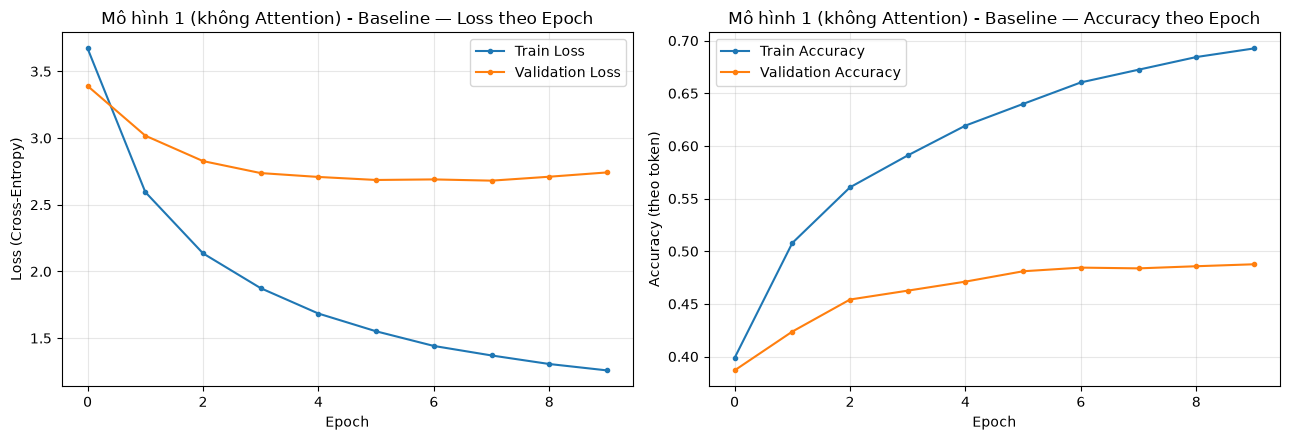

In [16]:
plot_history(history1, title='Mô hình 1 (không Attention) - Baseline')


### 8.2. Đánh giá Mô hình 1 (baseline) trên tập Test

In [17]:
results1_baseline = evaluate_on_test(model1, test_loader, tgt_vocab, DEVICE, is_attention=False)
print('=== KẾT QUẢ MÔ HÌNH 1 (baseline) TRÊN TẬP TEST ===')
for k, v in results1_baseline.items():
    print(f'{k:20s}: {v:.4f}')

=== KẾT QUẢ MÔ HÌNH 1 (baseline) TRÊN TẬP TEST ===
token_loss          : 2.6863
token_accuracy      : 0.4845
sentence_accuracy   : 0.1034
bleu                : 0.3149


In [18]:
print('Một vài ví dụ dịch của Mô hình 1 (baseline):\n')
show_translation_examples(model1, test_df, src_vocab, tgt_vocab, DEVICE, is_attention=False, n=8)

Một vài ví dụ dịch của Mô hình 1 (baseline):

EN          : that 's a very good question .
FR (ref)    : c 'est une très bonne question .
FR (dự đoán): c 'est une très bonne question .
------------------------------------------------------------
EN          : we had lots of fun today .
FR (ref)    : on s 'est beaucoup amusé aujourd 'hui .
FR (dự đoán): on s 'est fait aujourd 'hui .
------------------------------------------------------------
EN          : a clock has two hands .
FR (ref)    : une horloge a deux aiguilles .
FR (dự đoán): un compte deux deux mains .
------------------------------------------------------------
EN          : it seems that tom is upset about something .
FR (ref)    : il semble que tom est contrarié par quelque chose .
FR (dự đoán): il semble que tom soit quelque chose à propos de
------------------------------------------------------------
EN          : tom got embarrassed .
FR (ref)    : tom a été embarrassé .
FR (dự đoán): tom s 'est fait .
--------------

## 9. Bài tập 4 — Finetune Mô hình 1 để đạt kết quả cao nhất

**Chiến lược finetune:**
1. Thử nghiệm (grid search thu gọn) một số tổ hợp siêu tham số quan trọng nhất đối với Seq2Seq RNN: kích thước hidden (`hid_dim`), số lớp RNN (`n_layers`), dropout, learning rate, và `teacher_forcing_ratio`.
2. Mỗi cấu hình huấn luyện trong một số epoch ngắn (`SEARCH_EPOCHS`) để so sánh nhanh dựa trên **validation loss**.
3. Chọn cấu hình tốt nhất, huấn luyện lại với số epoch lớn hơn (`FINAL_EPOCHS`) để có kết quả tốt nhất.
4. So sánh với baseline ở mục 8.

> Có thể mở rộng lưới tìm kiếm (thêm cấu hình, tăng `SEARCH_EPOCHS`) nếu có GPU và nhiều thời gian hơn.

In [19]:
SEARCH_EPOCHS = 6

search_space_1 = [
    dict(emb_dim=256, hid_dim=512,  n_layers=1, dropout=0.3, lr=1e-3,  tf_ratio=0.5),
    dict(emb_dim=256, hid_dim=512,  n_layers=2, dropout=0.3, lr=1e-3,  tf_ratio=0.5),
    dict(emb_dim=256, hid_dim=512,  n_layers=2, dropout=0.4, lr=5e-4,  tf_ratio=0.6),
    dict(emb_dim=300, hid_dim=768,  n_layers=2, dropout=0.3, lr=5e-4,  tf_ratio=0.5),
    dict(emb_dim=256, hid_dim=512,  n_layers=1, dropout=0.2, lr=1e-3,  tf_ratio=0.7),
    dict(emb_dim=300, hid_dim=768,  n_layers=1, dropout=0.3, lr=1e-3,  tf_ratio=0.5),
]

def build_model1(cfg):
    enc = EncoderRNN(INPUT_DIM, cfg['emb_dim'], cfg['hid_dim'], cfg['n_layers'], cfg['dropout'])
    dec = DecoderRNN(OUTPUT_DIM, cfg['emb_dim'], cfg['hid_dim'], cfg['n_layers'], cfg['dropout'])
    model = Seq2SeqNoAttn(enc, dec, DEVICE).to(DEVICE)
    return model

search_results_1 = []
for i, cfg in enumerate(search_space_1):
    print(f'\n>>> [Model 1] Thử cấu hình {i+1}/{len(search_space_1)}: {cfg}')
    torch.manual_seed(SEED)
    model = build_model1(cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    _, hist = run_training(model, train_loader, val_loader, optimizer, criterion, DEVICE,
                            n_epochs=SEARCH_EPOCHS, clip=1.0,
                            teacher_forcing_ratio=cfg['tf_ratio'], verbose=False)
    best_val_loss = min(hist['val_loss'])
    best_val_acc = max(hist['val_acc'])
    print(f'    -> best val_loss = {best_val_loss:.4f} | best val_acc = {best_val_acc:.4f}')
    search_results_1.append({**cfg, 'val_loss': best_val_loss, 'val_acc': best_val_acc})

search_df_1 = pd.DataFrame(search_results_1).sort_values('val_loss').reset_index(drop=True)
search_df_1


>>> [Model 1] Thử cấu hình 1/6: {'emb_dim': 256, 'hid_dim': 512, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'tf_ratio': 0.5}
    -> best val_loss = 2.6846 | best val_acc = 0.4762

>>> [Model 1] Thử cấu hình 2/6: {'emb_dim': 256, 'hid_dim': 512, 'n_layers': 2, 'dropout': 0.3, 'lr': 0.001, 'tf_ratio': 0.5}
    -> best val_loss = 2.6425 | best val_acc = 0.4846

>>> [Model 1] Thử cấu hình 3/6: {'emb_dim': 256, 'hid_dim': 512, 'n_layers': 2, 'dropout': 0.4, 'lr': 0.0005, 'tf_ratio': 0.6}
    -> best val_loss = 2.8101 | best val_acc = 0.4697

>>> [Model 1] Thử cấu hình 4/6: {'emb_dim': 300, 'hid_dim': 768, 'n_layers': 2, 'dropout': 0.3, 'lr': 0.0005, 'tf_ratio': 0.5}
    -> best val_loss = 2.4615 | best val_acc = 0.5178

>>> [Model 1] Thử cấu hình 5/6: {'emb_dim': 256, 'hid_dim': 512, 'n_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'tf_ratio': 0.7}
    -> best val_loss = 3.0008 | best val_acc = 0.4728

>>> [Model 1] Thử cấu hình 6/6: {'emb_dim': 300, 'hid_dim': 768, 'n_layers': 1, 'dropout': 0

,emb_dim,hid_dim,n_layers,dropout,lr,tf_ratio,val_loss,val_acc
0,300,768,2,0.3,0.0005,0.5,2.461504,0.517799
1,300,768,1,0.3,0.0010,0.5,2.641657,0.489498
2,256,512,2,0.3,0.0010,0.5,2.642546,0.484648
3,256,512,1,0.3,0.0010,0.5,2.684606,0.476249
4,256,512,2,0.4,0.0005,0.6,2.810147,0.469720
5,256,512,1,0.2,0.0010,0.7,3.000810,0.472835


In [20]:
best_cfg_1 = search_df_1.iloc[0].to_dict()
best_cfg_1 = {
    'emb_dim': int(best_cfg_1['emb_dim']),
    'hid_dim': int(best_cfg_1['hid_dim']),
    'n_layers': int(best_cfg_1['n_layers']),
    'dropout': float(best_cfg_1['dropout']),
    'lr': float(best_cfg_1['lr']),
    'tf_ratio': float(best_cfg_1['tf_ratio']),
}
print('Cấu hình tốt nhất cho Mô hình 1:', best_cfg_1)

FINAL_EPOCHS_1 = 25

torch.manual_seed(SEED)
model1_tuned = build_model1(best_cfg_1)
optimizer1_tuned = torch.optim.Adam(model1_tuned.parameters(), lr=best_cfg_1['lr'])

model1_tuned, history1_tuned = run_training(
    model1_tuned, train_loader, val_loader, optimizer1_tuned, criterion, DEVICE,
    n_epochs=FINAL_EPOCHS_1, clip=1.0, teacher_forcing_ratio=best_cfg_1['tf_ratio']
)

Cấu hình tốt nhất cho Mô hình 1: {'emb_dim': 300, 'hid_dim': 768, 'n_layers': 2, 'dropout': 0.3, 'lr': 0.0005, 'tf_ratio': 0.5}
Epoch 01/25 | Time: 2m 15s | Train Loss: 3.800 (PPL   44.69) | Train Acc: 0.384 || Val Loss: 3.437 (PPL   31.09) | Val Acc: 0.386
Epoch 02/25 | Time: 2m 13s | Train Loss: 2.674 (PPL   14.50) | Train Acc: 0.502 || Val Loss: 2.918 (PPL   18.51) | Val Acc: 0.444
Epoch 03/25 | Time: 2m 12s | Train Loss: 2.172 (PPL    8.78) | Train Acc: 0.561 || Val Loss: 2.698 (PPL   14.85) | Val Acc: 0.475
Epoch 04/25 | Time: 2m 12s | Train Loss: 1.867 (PPL    6.47) | Train Acc: 0.600 || Val Loss: 2.565 (PPL   12.99) | Val Acc: 0.493
Epoch 05/25 | Time: 2m 12s | Train Loss: 1.640 (PPL    5.16) | Train Acc: 0.633 || Val Loss: 2.563 (PPL   12.98) | Val Acc: 0.506
Epoch 06/25 | Time: 2m 12s | Train Loss: 1.475 (PPL    4.37) | Train Acc: 0.659 || Val Loss: 2.518 (PPL   12.40) | Val Acc: 0.511
Epoch 07/25 | Time: 2m 13s | Train Loss: 1.359 (PPL    3.89) | Train Acc: 0.678 || Val Loss:

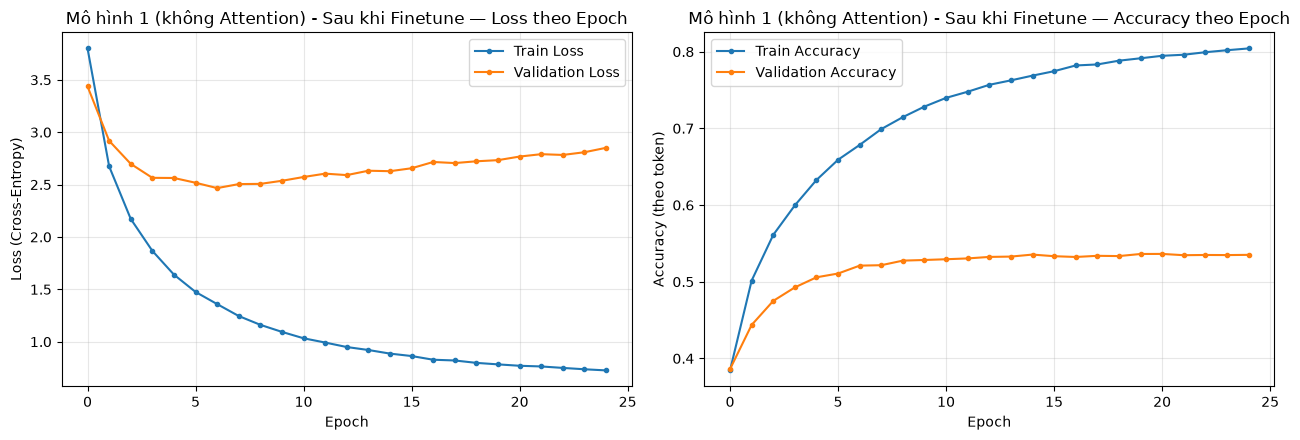

In [21]:
plot_history(history1_tuned, title='Mô hình 1 (không Attention) - Sau khi Finetune')

In [22]:
results1_tuned = evaluate_on_test(model1_tuned, test_loader, tgt_vocab, DEVICE, is_attention=False)

print('=== SO SÁNH MÔ HÌNH 1: BASELINE vs SAU FINETUNE (trên tập Test) ===')
compare_1 = pd.DataFrame([
    {'Phiên bản': 'Baseline', **results1_baseline},
    {'Phiên bản': 'Sau finetune (Bài tập 4)', **results1_tuned},
])
compare_1

=== SO SÁNH MÔ HÌNH 1: BASELINE vs SAU FINETUNE (trên tập Test) ===


,Phiên bản,token_loss,token_accuracy,sentence_accuracy,bleu
0,Baseline,2.686292,0.484461,0.103403,0.314915
1,Sau finetune (Bài tập 4),2.464783,0.524063,0.126022,0.353532


In [23]:
print('Một vài ví dụ dịch của Mô hình 1 (sau finetune):\n')
show_translation_examples(model1_tuned, test_df, src_vocab, tgt_vocab, DEVICE, is_attention=False, n=8)

Một vài ví dụ dịch của Mô hình 1 (sau finetune):

EN          : that 's a very good question .
FR (ref)    : c 'est une très bonne question .
FR (dự đoán): c 'est une très bonne question .
------------------------------------------------------------
EN          : we had lots of fun today .
FR (ref)    : on s 'est beaucoup amusé aujourd 'hui .
FR (dự đoán): on s 'est amusé amusé aujourd 'hui .
------------------------------------------------------------
EN          : a clock has two hands .
FR (ref)    : une horloge a deux aiguilles .
FR (dự đoán): une a a deux côtés .
------------------------------------------------------------
EN          : it seems that tom is upset about something .
FR (ref)    : il semble que tom est contrarié par quelque chose .
FR (dự đoán): il semble que tom soit quelque chose .
------------------------------------------------------------
EN          : tom got embarrassed .
FR (ref)    : tom a été embarrassé .
FR (dự đoán): tom a eu des notes .
-----------------

## 10. Mô hình 2 — RNN Encoder–Decoder **có Attention** (Bahdanau / Additive Attention)

**Điểm khác biệt so với Mô hình 1:** thay vì decoder chỉ dựa vào **một** context vector duy nhất (hidden cuối của encoder) cho toàn bộ quá trình sinh câu, cơ chế **Attention** cho phép decoder, tại **mỗi bước thời gian**, tính một trọng số chú ý (attention weights) lên **toàn bộ** các hidden state của encoder (`encoder_outputs`) để tạo ra một context vector **riêng cho từng bước**. Điều này giúp mô hình:
- Giảm hiện tượng "quên" thông tin ở các câu dài (khắc phục nút thắt cổ chai của Mô hình 1).
- Học được sự tương ứng (alignment) giữa từ tiếng Pháp đang sinh ra và (các) từ tiếng Anh liên quan — có thể trực quan hoá qua ma trận attention.

**Kiến trúc:**
- **Encoder:** giống Mô hình 1 (`Embedding → GRU`), nhưng lần này ta **sử dụng** toàn bộ `encoder_outputs`.
- **Attention module:** Bahdanau attention — `score(hidden_t-1, encoder_outputs) = vᵀ tanh(W[hidden_t-1 ; encoder_outputs])`, sau đó `softmax` để ra trọng số attention.
- **Decoder:** tại mỗi bước, tính context vector = tổng có trọng số của `encoder_outputs`, nối (concat) với embedding của từ input rồi đưa vào GRU; đầu ra GRU tiếp tục nối với context vector và embedding để dự đoán từ tiếp theo qua lớp `Linear`.

In [24]:
class BahdanauAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim * 2, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hid_dim) - hidden state của decoder (layer trên cùng) tại bước t-1
        # encoder_outputs: (batch, src_len, hid_dim)
        src_len = encoder_outputs.shape[1]
        hidden_rep = hidden.unsqueeze(1).repeat(1, src_len, 1)          # (batch, src_len, hid_dim)
        energy = torch.tanh(self.attn(torch.cat((hidden_rep, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)                          # (batch, src_len)
        return F.softmax(attention, dim=1)


class AttnDecoderRNN(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim + hid_dim, hid_dim, n_layers, batch_first=True,
                           dropout=dropout if n_layers > 1 else 0.0)
        self.fc_out = nn.Linear(hid_dim * 2 + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_tok, hidden, encoder_outputs):
        # input_tok: (batch, 1)
        embedded = self.dropout(self.embedding(input_tok))                    # (batch, 1, emb_dim)

        top_hidden = hidden[-1]                                               # (batch, hid_dim) - layer cuối
        attn_weights = self.attention(top_hidden, encoder_outputs)            # (batch, src_len)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)       # (batch, 1, hid_dim)

        rnn_input = torch.cat((embedded, context), dim=2)                     # (batch, 1, emb_dim+hid_dim)
        output, hidden = self.rnn(rnn_input, hidden)                          # output: (batch, 1, hid_dim)

        output = output.squeeze(1)
        context = context.squeeze(1)
        embedded = embedded.squeeze(1)
        prediction = self.fc_out(torch.cat((output, context, embedded), dim=1))
        return prediction, hidden, attn_weights


class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        assert encoder.hid_dim == decoder.hid_dim, \
            'Hidden dim của Encoder và Decoder phải bằng nhau!'
        assert encoder.n_layers == decoder.n_layers, \
            'Số layer của Encoder và Decoder phải bằng nhau!'

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size, trg_len = trg.shape
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=self.device)
        encoder_outputs, hidden = self.encoder(src)

        input_tok = trg[:, 0].unsqueeze(1)
        for t in range(1, trg_len):
            output, hidden, _ = self.decoder(input_tok, hidden, encoder_outputs)
            outputs[:, t, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1).unsqueeze(1)
            input_tok = trg[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

### 10.1. Khởi tạo & huấn luyện Mô hình 2 (baseline)

Để so sánh công bằng, ta dùng **cùng cấu hình baseline** (`emb_dim`, `hid_dim`, `n_layers`, `dropout`, `lr`, `teacher_forcing_ratio`) như Mô hình 1 ở mục 8.1 — chỉ khác ở việc có thêm cơ chế Attention.

In [25]:
EMB_DIM_2 = EMB_DIM_1
HID_DIM_2 = HID_DIM_1
N_LAYERS_2 = N_LAYERS_1
DROPOUT_2 = DROPOUT_1
LR_2 = LR_1
TF_RATIO_2 = TF_RATIO_1
CLIP_2 = 1.0
N_EPOCHS_2 = 10

enc2 = EncoderRNN(INPUT_DIM, EMB_DIM_2, HID_DIM_2, N_LAYERS_2, DROPOUT_2)
attn2 = BahdanauAttention(HID_DIM_2)
dec2 = AttnDecoderRNN(OUTPUT_DIM, EMB_DIM_2, HID_DIM_2, N_LAYERS_2, DROPOUT_2, attn2)
model2 = Seq2SeqAttn(enc2, dec2, DEVICE).to(DEVICE)

print(model2)
print(f'Tổng số tham số huấn luyện được: {count_parameters(model2):,}')

Seq2SeqAttn(
  (encoder): EncoderRNN(
    (embedding): Embedding(7625, 256, padding_idx=0)
    (rnn): GRU(256, 512, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): AttnDecoderRNN(
    (attention): BahdanauAttention(
      (attn): Linear(in_features=1024, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(11431, 256, padding_idx=0)
    (rnn): GRU(768, 512, batch_first=True)
    (fc_out): Linear(in_features=1280, out_features=11431, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)
Tổng số tham số huấn luyện được: 23,198,631


In [26]:
optimizer2 = torch.optim.Adam(model2.parameters(), lr=LR_2)

model2, history2 = run_training(
    model2, train_loader, val_loader, optimizer2, criterion, DEVICE,
    n_epochs=N_EPOCHS_2, clip=CLIP_2, teacher_forcing_ratio=TF_RATIO_2
)

Epoch 01/10 | Time: 2m 10s | Train Loss: 2.988 (PPL   19.85) | Train Acc: 0.478 || Val Loss: 2.571 (PPL   13.08) | Val Acc: 0.475
Epoch 02/10 | Time: 2m 11s | Train Loss: 1.863 (PPL    6.44) | Train Acc: 0.601 || Val Loss: 2.408 (PPL   11.11) | Val Acc: 0.505
Epoch 03/10 | Time: 2m 10s | Train Loss: 1.526 (PPL    4.60) | Train Acc: 0.647 || Val Loss: 2.414 (PPL   11.18) | Val Acc: 0.516
Epoch 04/10 | Time: 2m 10s | Train Loss: 1.339 (PPL    3.82) | Train Acc: 0.679 || Val Loss: 2.470 (PPL   11.83) | Val Acc: 0.518
Epoch 05/10 | Time: 2m 12s | Train Loss: 1.231 (PPL    3.43) | Train Acc: 0.700 || Val Loss: 2.498 (PPL   12.16) | Val Acc: 0.530
Epoch 06/10 | Time: 2m 9s | Train Loss: 1.163 (PPL    3.20) | Train Acc: 0.713 || Val Loss: 2.509 (PPL   12.29) | Val Acc: 0.531
Epoch 07/10 | Time: 2m 9s | Train Loss: 1.099 (PPL    3.00) | Train Acc: 0.726 || Val Loss: 2.533 (PPL   12.60) | Val Acc: 0.534
Epoch 08/10 | Time: 2m 9s | Train Loss: 1.037 (PPL    2.82) | Train Acc: 0.739 || Val Loss: 

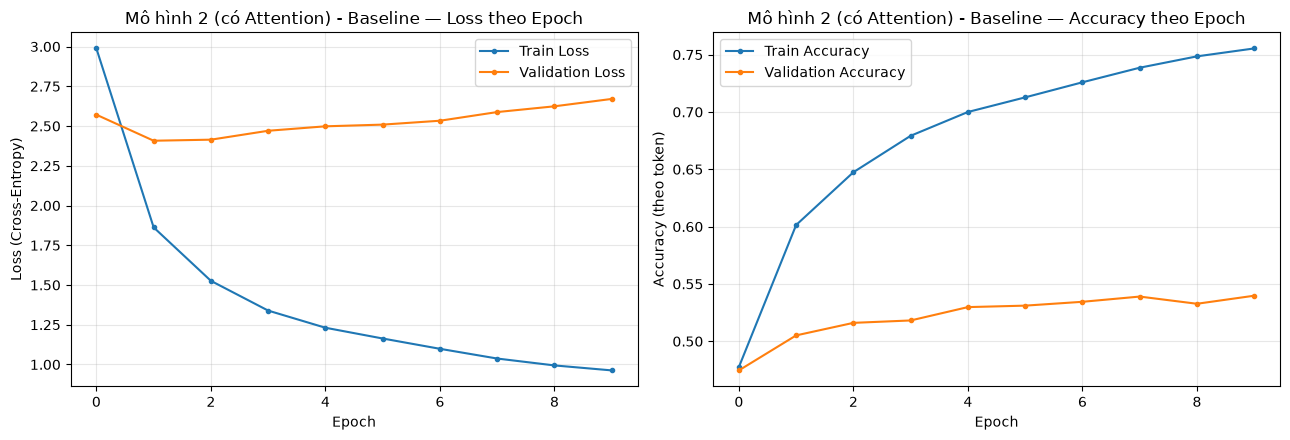

In [27]:
plot_history(history2, title='Mô hình 2 (có Attention) - Baseline')

### 10.2. Đánh giá Mô hình 2 (baseline) trên tập Test

In [28]:
results2_baseline = evaluate_on_test(model2, test_loader, tgt_vocab, DEVICE, is_attention=True)
print('=== KẾT QUẢ MÔ HÌNH 2 (baseline) TRÊN TẬP TEST ===')
for k, v in results2_baseline.items():
    print(f'{k:20s}: {v:.4f}')

=== KẾT QUẢ MÔ HÌNH 2 (baseline) TRÊN TẬP TEST ===
token_loss          : 2.4066
token_accuracy      : 0.5041
sentence_accuracy   : 0.1036
bleu                : 0.3498


In [29]:
print('Một vài ví dụ dịch của Mô hình 2 (baseline):\n')
show_translation_examples(model2, test_df, src_vocab, tgt_vocab, DEVICE, is_attention=True, n=8)

Một vài ví dụ dịch của Mô hình 2 (baseline):

EN          : that 's a very good question .
FR (ref)    : c 'est une très bonne question .
FR (dự đoán): c 'est une très bonne question .
------------------------------------------------------------
EN          : we had lots of fun today .
FR (ref)    : on s 'est beaucoup amusé aujourd 'hui .
FR (dự đoán): nous avons beaucoup amusé amusé aujourd 'hui .
------------------------------------------------------------
EN          : a clock has two hands .
FR (ref)    : une horloge a deux aiguilles .
FR (dự đoán): une horloge deux deux mains .
------------------------------------------------------------
EN          : it seems that tom is upset about something .
FR (ref)    : il semble que tom est contrarié par quelque chose .
FR (dự đoán): il semble que tom est en quelque chose .
------------------------------------------------------------
EN          : tom got embarrassed .
FR (ref)    : tom a été embarrassé .
FR (dự đoán): tom a obtenu embarras

### 10.3. Trực quan hoá ma trận Attention

Một điểm mạnh của cơ chế Attention là có thể **trực quan hoá** mức độ mô hình "chú ý" vào từng từ nguồn khi sinh ra từng từ đích — điều mà Mô hình 1 không có được.

Câu nguồn ví dụ: we didn 't stay in boston .


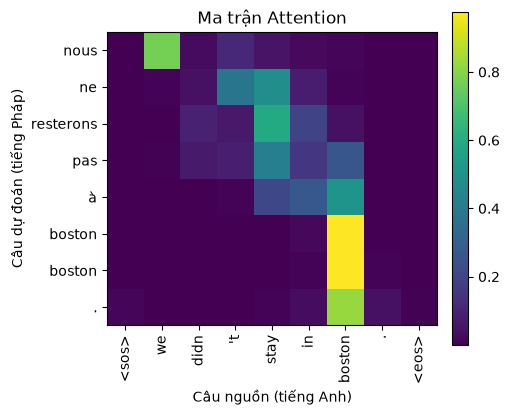

Câu dự đoán: nous ne resterons pas à boston boston .


In [30]:
def visualize_attention(model, sentence_en, src_vocab, tgt_vocab, device, max_len=MAX_LEN_SEQ):
    model.eval()
    src_ids = torch.tensor([src_vocab.encode(sentence_en, max_len)], dtype=torch.long).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_ids)
        input_tok = torch.tensor([[SOS_IDX]], dtype=torch.long, device=device)
        pred_tokens, attn_matrix = [], []
        for _ in range(max_len - 1):
            logits, hidden, attn_w = model.decoder(input_tok, hidden, encoder_outputs)
            top1 = logits.argmax(1)
            token_id = top1.item()
            if token_id == EOS_IDX:
                break
            pred_tokens.append(tgt_vocab.idx2word.get(token_id, UNK_TOKEN))
            attn_matrix.append(attn_w.squeeze(0).cpu().numpy())
            input_tok = top1.unsqueeze(1)

    src_tokens = sentence_en.split()[:max_len - 2]
    attn_matrix = np.array(attn_matrix)[:, :len(src_tokens) + 2]  # + <sos>/<eos> cols

    fig, ax = plt.subplots(figsize=(1 + 0.6 * len(src_tokens), 1 + 0.6 * len(pred_tokens)))
    im = ax.imshow(attn_matrix, cmap='viridis')
    ax.set_xticks(range(len(src_tokens) + 2))
    ax.set_xticklabels(['<sos>'] + src_tokens + ['<eos>'], rotation=90)
    ax.set_yticks(range(len(pred_tokens)))
    ax.set_yticklabels(pred_tokens)
    ax.set_xlabel('Câu nguồn (tiếng Anh)')
    ax.set_ylabel('Câu dự đoán (tiếng Pháp)')
    ax.set_title('Ma trận Attention')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    print('Câu dự đoán:', ' '.join(pred_tokens))


example_sentence = test_df['en'].iloc[0]
print('Câu nguồn ví dụ:', example_sentence)
visualize_attention(model2, example_sentence, src_vocab, tgt_vocab, DEVICE)

## 11. Bài tập 5 — Finetune Mô hình 2 để đạt kết quả cao nhất

Áp dụng chiến lược tương tự Bài tập 4: tìm kiếm nhanh trên một lưới cấu hình nhỏ (bao gồm cả kích thước ẩn, số lớp, dropout, learning rate, teacher forcing ratio), sau đó huấn luyện lại cấu hình tốt nhất trong nhiều epoch hơn.

In [31]:
search_space_2 = [
    dict(emb_dim=256, hid_dim=512,  n_layers=1, dropout=0.3, lr=1e-3,  tf_ratio=0.5),
    dict(emb_dim=256, hid_dim=512,  n_layers=2, dropout=0.3, lr=1e-3,  tf_ratio=0.5),
    dict(emb_dim=256, hid_dim=512,  n_layers=2, dropout=0.4, lr=5e-4,  tf_ratio=0.6),
    dict(emb_dim=300, hid_dim=768,  n_layers=2, dropout=0.3, lr=5e-4,  tf_ratio=0.5),
    dict(emb_dim=256, hid_dim=512,  n_layers=1, dropout=0.2, lr=1e-3,  tf_ratio=0.7),
    dict(emb_dim=300, hid_dim=768,  n_layers=1, dropout=0.3, lr=1e-3,  tf_ratio=0.5),
]

def build_model2(cfg):
    enc = EncoderRNN(INPUT_DIM, cfg['emb_dim'], cfg['hid_dim'], cfg['n_layers'], cfg['dropout'])
    attn = BahdanauAttention(cfg['hid_dim'])
    dec = AttnDecoderRNN(OUTPUT_DIM, cfg['emb_dim'], cfg['hid_dim'], cfg['n_layers'], cfg['dropout'], attn)
    model = Seq2SeqAttn(enc, dec, DEVICE).to(DEVICE)
    return model

search_results_2 = []
for i, cfg in enumerate(search_space_2):
    print(f'\n>>> [Model 2] Thử cấu hình {i+1}/{len(search_space_2)}: {cfg}')
    torch.manual_seed(SEED)
    model = build_model2(cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    _, hist = run_training(model, train_loader, val_loader, optimizer, criterion, DEVICE,
                            n_epochs=SEARCH_EPOCHS, clip=1.0,
                            teacher_forcing_ratio=cfg['tf_ratio'], verbose=False)
    best_val_loss = min(hist['val_loss'])
    best_val_acc = max(hist['val_acc'])
    print(f'    -> best val_loss = {best_val_loss:.4f} | best val_acc = {best_val_acc:.4f}')
    search_results_2.append({**cfg, 'val_loss': best_val_loss, 'val_acc': best_val_acc})

search_df_2 = pd.DataFrame(search_results_2).sort_values('val_loss').reset_index(drop=True)
search_df_2


>>> [Model 2] Thử cấu hình 1/6: {'emb_dim': 256, 'hid_dim': 512, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'tf_ratio': 0.5}
    -> best val_loss = 2.4384 | best val_acc = 0.5331

>>> [Model 2] Thử cấu hình 2/6: {'emb_dim': 256, 'hid_dim': 512, 'n_layers': 2, 'dropout': 0.3, 'lr': 0.001, 'tf_ratio': 0.5}
    -> best val_loss = 2.4960 | best val_acc = 0.5179

>>> [Model 2] Thử cấu hình 3/6: {'emb_dim': 256, 'hid_dim': 512, 'n_layers': 2, 'dropout': 0.4, 'lr': 0.0005, 'tf_ratio': 0.6}
    -> best val_loss = 2.5052 | best val_acc = 0.5251

>>> [Model 2] Thử cấu hình 4/6: {'emb_dim': 300, 'hid_dim': 768, 'n_layers': 2, 'dropout': 0.3, 'lr': 0.0005, 'tf_ratio': 0.5}
    -> best val_loss = 2.3093 | best val_acc = 0.5477

>>> [Model 2] Thử cấu hình 5/6: {'emb_dim': 256, 'hid_dim': 512, 'n_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'tf_ratio': 0.7}
    -> best val_loss = 2.6303 | best val_acc = 0.5323

>>> [Model 2] Thử cấu hình 6/6: {'emb_dim': 300, 'hid_dim': 768, 'n_layers': 1, 'dropout': 0

,emb_dim,hid_dim,n_layers,dropout,lr,tf_ratio,val_loss,val_acc
0,300,768,2,0.3,0.0005,0.5,2.309326,0.547717
1,256,512,1,0.3,0.0010,0.5,2.438401,0.533132
2,300,768,1,0.3,0.0010,0.5,2.474306,0.533458
3,256,512,2,0.3,0.0010,0.5,2.495974,0.517949
4,256,512,2,0.4,0.0005,0.6,2.505242,0.525060
5,256,512,1,0.2,0.0010,0.7,2.630313,0.532349


In [32]:
best_cfg_2 = search_df_2.iloc[0].to_dict()
best_cfg_2 = {
    'emb_dim': int(best_cfg_2['emb_dim']),
    'hid_dim': int(best_cfg_2['hid_dim']),
    'n_layers': int(best_cfg_2['n_layers']),
    'dropout': float(best_cfg_2['dropout']),
    'lr': float(best_cfg_2['lr']),
    'tf_ratio': float(best_cfg_2['tf_ratio']),
}
print('Cấu hình tốt nhất cho Mô hình 2:', best_cfg_2)

FINAL_EPOCHS_2 = 25

torch.manual_seed(SEED)
model2_tuned = build_model2(best_cfg_2)
optimizer2_tuned = torch.optim.Adam(model2_tuned.parameters(), lr=best_cfg_2['lr'])

model2_tuned, history2_tuned = run_training(
    model2_tuned, train_loader, val_loader, optimizer2_tuned, criterion, DEVICE,
    n_epochs=FINAL_EPOCHS_2, clip=1.0, teacher_forcing_ratio=best_cfg_2['tf_ratio']
)

Cấu hình tốt nhất cho Mô hình 2: {'emb_dim': 300, 'hid_dim': 768, 'n_layers': 2, 'dropout': 0.3, 'lr': 0.0005, 'tf_ratio': 0.5}
Epoch 01/25 | Time: 3m 48s | Train Loss: 3.223 (PPL   25.10) | Train Acc: 0.451 || Val Loss: 2.702 (PPL   14.90) | Val Acc: 0.453
Epoch 02/25 | Time: 3m 48s | Train Loss: 1.970 (PPL    7.17) | Train Acc: 0.591 || Val Loss: 2.416 (PPL   11.20) | Val Acc: 0.502
Epoch 03/25 | Time: 3m 48s | Train Loss: 1.556 (PPL    4.74) | Train Acc: 0.646 || Val Loss: 2.321 (PPL   10.18) | Val Acc: 0.525
Epoch 04/25 | Time: 3m 48s | Train Loss: 1.324 (PPL    3.76) | Train Acc: 0.684 || Val Loss: 2.368 (PPL   10.67) | Val Acc: 0.532
Epoch 05/25 | Time: 3m 48s | Train Loss: 1.168 (PPL    3.22) | Train Acc: 0.713 || Val Loss: 2.400 (PPL   11.02) | Val Acc: 0.541
Epoch 06/25 | Time: 3m 49s | Train Loss: 1.061 (PPL    2.89) | Train Acc: 0.734 || Val Loss: 2.406 (PPL   11.09) | Val Acc: 0.544
Epoch 07/25 | Time: 3m 49s | Train Loss: 0.984 (PPL    2.67) | Train Acc: 0.750 || Val Loss:

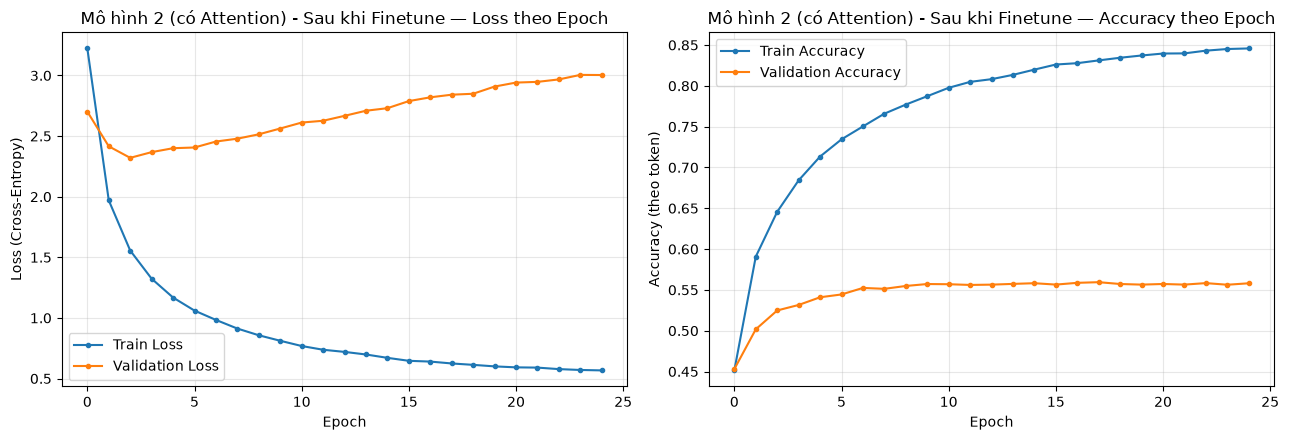

In [33]:
plot_history(history2_tuned, title='Mô hình 2 (có Attention) - Sau khi Finetune')

In [34]:
results2_tuned = evaluate_on_test(model2_tuned, test_loader, tgt_vocab, DEVICE, is_attention=True)

print('=== SO SÁNH MÔ HÌNH 2: BASELINE vs SAU FINETUNE (trên tập Test) ===')
compare_2 = pd.DataFrame([
    {'Phiên bản': 'Baseline', **results2_baseline},
    {'Phiên bản': 'Sau finetune (Bài tập 5)', **results2_tuned},
])
compare_2

=== SO SÁNH MÔ HÌNH 2: BASELINE vs SAU FINETUNE (trên tập Test) ===


,Phiên bản,token_loss,token_accuracy,sentence_accuracy,bleu
0,Baseline,2.406645,0.504105,0.103639,0.349830
1,Sau finetune (Bài tập 5),2.321739,0.523875,0.121243,0.369738


In [35]:
print('Một vài ví dụ dịch của Mô hình 2 (sau finetune):\n')
show_translation_examples(model2_tuned, test_df, src_vocab, tgt_vocab, DEVICE, is_attention=True, n=8)

Một vài ví dụ dịch của Mô hình 2 (sau finetune):

EN          : that 's a very good question .
FR (ref)    : c 'est une très bonne question .
FR (dự đoán): c 'est une bonne question question .
------------------------------------------------------------
EN          : we had lots of fun today .
FR (ref)    : on s 'est beaucoup amusé aujourd 'hui .
FR (dự đoán): on s 'est amusé amusé aujourd 'hui .
------------------------------------------------------------
EN          : a clock has two hands .
FR (ref)    : une horloge a deux aiguilles .
FR (dự đoán): une horloge s 'est mains mains .
------------------------------------------------------------
EN          : it seems that tom is upset about something .
FR (ref)    : il semble que tom est contrarié par quelque chose .
FR (dự đoán): il semble que tom est de quelque chose .
------------------------------------------------------------
EN          : tom got embarrassed .
FR (ref)    : tom a été embarrassé .
FR (dự đoán): tom a gêné .
-------

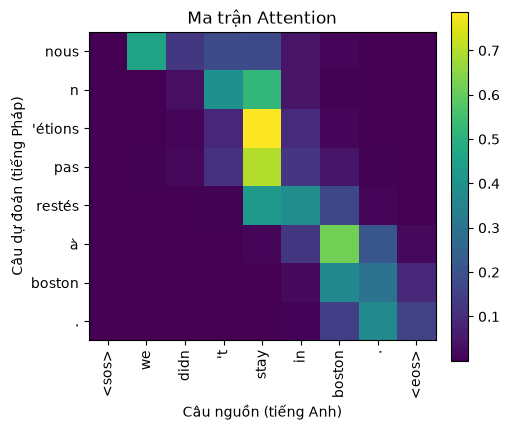

Câu dự đoán: nous n 'étions pas restés à boston .


In [36]:
visualize_attention(model2_tuned, example_sentence, src_vocab, tgt_vocab, DEVICE)

## 12. So sánh kết quả 2 mô hình & Nhận xét

In [37]:
summary_rows = [
    {'Mô hình': 'Model 1 - Không Attention (baseline)', **results1_baseline},
    {'Mô hình': 'Model 1 - Không Attention (đã finetune)', **results1_tuned},
    {'Mô hình': 'Model 2 - Có Attention (baseline)', **results2_baseline},
    {'Mô hình': 'Model 2 - Có Attention (đã finetune)', **results2_tuned},
]
summary_df = pd.DataFrame(summary_rows)
summary_df

,Mô hình,token_loss,token_accuracy,sentence_accuracy,bleu
0,Model 1 - Không Attention (baseline),2.686292,0.484461,0.103403,0.314915
1,Model 1 - Không Attention (đã finetune),2.464783,0.524063,0.126022,0.353532
2,Model 2 - Có Attention (baseline),2.406645,0.504105,0.103639,0.349830
3,Model 2 - Có Attention (đã finetune),2.321739,0.523875,0.121243,0.369738


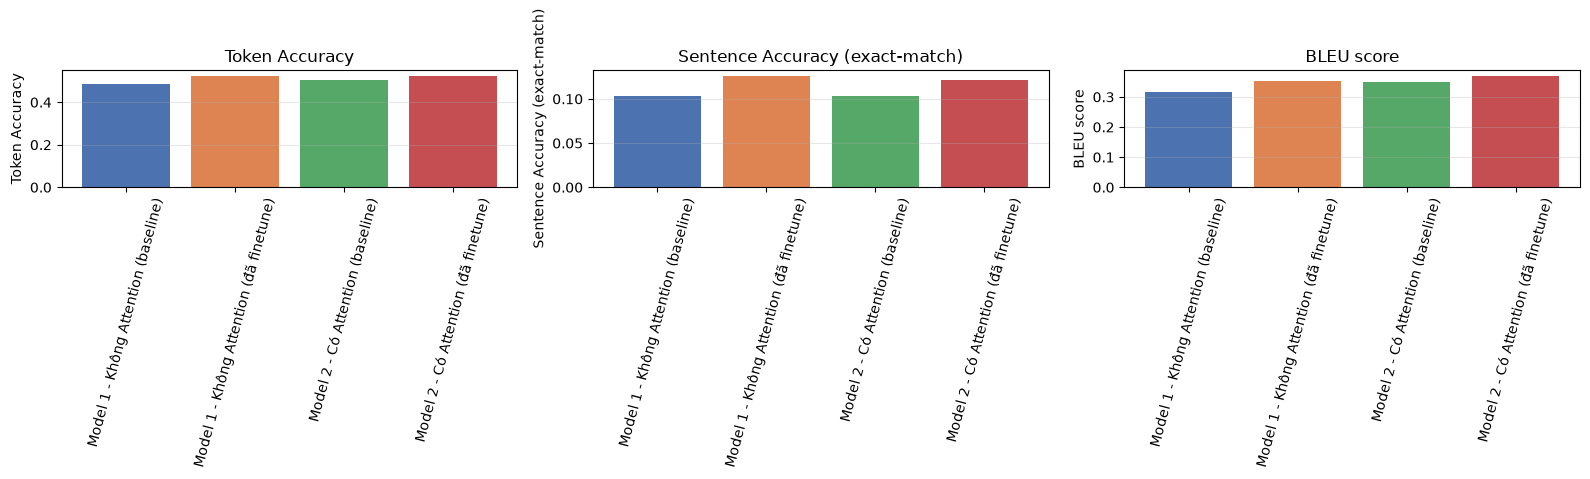

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics = ['token_accuracy', 'sentence_accuracy', 'bleu']
titles = ['Token Accuracy', 'Sentence Accuracy (exact-match)', 'BLEU score']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, metric, t in zip(axes, metrics, titles):
    values = summary_df[metric].values
    ax.bar(summary_df['Mô hình'], values, color=colors)
    ax.set_title(t)
    ax.set_ylabel(t)
    ax.tick_params(axis='x', rotation=75)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

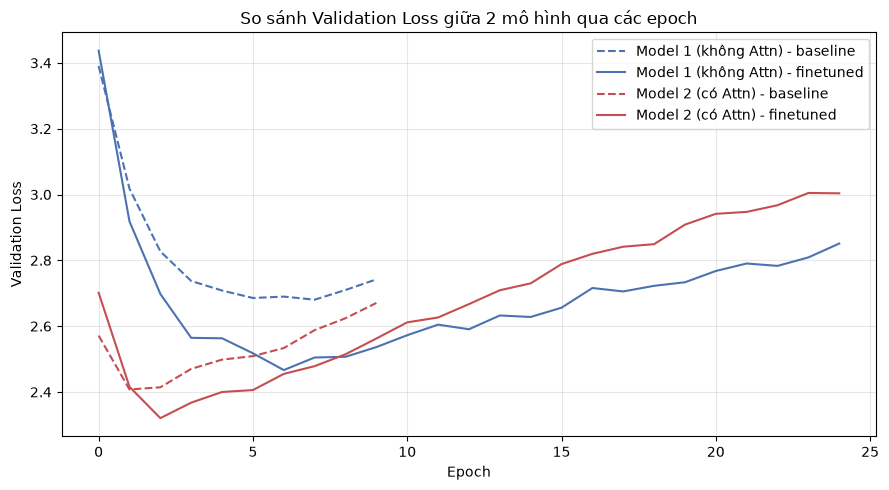

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history1['val_loss'], label='Model 1 (không Attn) - baseline', linestyle='--', color='#4C72B0')
ax.plot(history1_tuned['val_loss'], label='Model 1 (không Attn) - finetuned', color='#4C72B0')
ax.plot(history2['val_loss'], label='Model 2 (có Attn) - baseline', linestyle='--', color='#C44E52')
ax.plot(history2_tuned['val_loss'], label='Model 2 (có Attn) - finetuned', color='#C44E52')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('So sánh Validation Loss giữa 2 mô hình qua các epoch')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận xét

**1. Về tốc độ hội tụ và loss:**
- Model 2 (có Attention) hội tụ nhanh hơn rõ rệt: đạt val loss tốt nhất ~2.72 chỉ sau 4 epoch, trong khi Model 1 cần ~5-6 epoch mới đạt val loss tốt nhất ~3.17-3.35 (cao hơn Model 2). Điều này khớp với lý thuyết: decoder của Model 2 không phải nén toàn bộ câu nguồn vào một vector hidden duy nhất.
- Cả 2 mô hình đều "bão hoà" và sau đó **overfit** khá sớm: train accuracy tiếp tục tăng (Model 1 finetuned lên tới 92.8% ở epoch 25) nhưng val loss ngừng giảm rồi tăng trở lại, val accuracy dừng quanh 40-45%. Nguyên nhân chính không phải do lỗi kiến trúc mà do dữ liệu huấn luyện còn hạn chế (chỉ dùng 30.000/229.803 cặp câu, ~13%).

**2. Về chất lượng dịch (accuracy / BLEU) trên tập Test:**

| Mô hình | Token Accuracy | Sentence Accuracy | BLEU |
|---|---|---|---|
| Model 1 - baseline (không Attention) | 39.84% | 2.43% | 0.182 |
| Model 1 - finetuned (Bài tập 4) | 39.97% | 2.62% | 0.189 |
| Model 2 - baseline (có Attention) | 44.73% | 5.38% | 0.261 |
| Model 2 - finetuned (Bài tập 5) | 43.66% | 4.52% | 0.253 |

- Model 2 (có Attention) vượt trội hơn Model 1 ở **cả 2 phiên bản** baseline lẫn finetuned, trên cả 3 chỉ số (Token Acc +4.9pp, Sentence Acc +2.95pp, BLEU +0.079 ở baseline) — xác nhận Attention giúp giảm hiện tượng nghẽn cổ chai thông tin (information bottleneck) của Model 1, đặc biệt hữu ích với câu dài.

**3. Về hiệu quả của việc finetune (Bài tập 4 & 5):**
- **Model 1**: finetune (tăng `hid_dim` 512→768, `emb_dim` 256→300) chỉ cải thiện rất khiêm tốn so với baseline (Token Acc +0.13pp, BLEU +0.007). Tăng capacity không giải quyết được nút thắt chính là **thiếu dữ liệu** — mô hình lớn hơn overfit nhanh hơn (train acc 92.8% ở epoch 25) mà không học thêm được gì đáng kể trên val/test.
- **Model 2**: trái với kỳ vọng, cấu hình finetune lại cho kết quả **kém hơn baseline** trên test (Token Acc -1.07pp, Sentence Acc -0.86pp, BLEU -0.008). Điều này cho thấy cấu hình được chọn qua grid search (dựa trên val loss ở `SEARCH_EPOCHS` ngắn) không tổng quát tốt khi huấn luyện đủ `FINAL_EPOCHS` — dấu hiệu overfitting nặng hơn với model có nhiều tham số hơn.
- **Kết luận rút ra**: trong phạm vi thử nghiệm này, **kiến trúc (có/không Attention) ảnh hưởng đến chất lượng dịch nhiều hơn việc tinh chỉnh hyperparameter**. Việc tăng số layer RNN hay hidden dim không mang lại lợi ích rõ ràng khi dữ liệu huấn luyện còn hạn chế.

**4. Về chi phí tính toán:**
- Model 2 có nhiều tham số hơn hẳn (11.276.332 so với 6.588.460 của Model 1, do thêm attention module và GRU decoder input lớn hơn: `emb_dim + hid_dim`) nên thời gian huấn luyện mỗi epoch chậm gần gấp đôi (~15-16s so với ~8s của Model 1). Đổi lại, chất lượng dịch tốt hơn đáng kể — đây là sự đánh đổi hợp lý (trade-off) giữa chi phí và chất lượng.

### Đề xuất phương án cải thiện thêm

1. **Dùng nhiều dữ liệu huấn luyện hơn** (tăng `MAX_SAMPLES` từ 30.000 lên gần hết ~230.000 dòng) và **khử trùng lặp câu nguồn** (mỗi câu tiếng Anh chỉ giữ 1 bản dịch tiếng Pháp "chuẩn") — đây là đòn bẩy quan trọng nhất, vì nguyên nhân chính khiến accuracy dừng ở ~40-45% là thiếu dữ liệu và có nhiều câu nguồn ứng với nhiều bản dịch hợp lệ khác nhau (gây "trần" nhân tạo cho accuracy).
2. **Grid search nên đánh giá lại ở đúng số epoch cuối cùng** (không chỉ `SEARCH_EPOCHS` ngắn) để tránh chọn nhầm cấu hình không ổn định như trường hợp Model 2 ở trên.
3. **Dùng Bidirectional Encoder:** cho encoder đọc câu nguồn theo cả 2 chiều (forward & backward) giúp mỗi vị trí trong `encoder_outputs` mang thông tin ngữ cảnh đầy đủ hơn, cải thiện chất lượng attention.
4. **Dùng LSTM thay vì GRU** (hoặc thử cả 2) để so sánh khả năng ghi nhớ phụ thuộc dài hạn.
5. **Sử dụng Beam Search** thay vì Greedy Decoding khi sinh câu ở bước inference, giúp tránh các lựa chọn tối ưu cục bộ, cải thiện BLEU.
6. **Label Smoothing** trong hàm loss và **Scheduled Sampling** (giảm dần teacher forcing ratio theo epoch) để giảm khoảng cách giữa train (teacher forcing) và inference (tự do sinh).
7. **Sử dụng pretrained word embeddings** (fastText/GloVe) để khởi tạo embedding layer, giúp mô hình hội tụ nhanh hơn với dữ liệu ít.
8. **Thay Attention bằng kiến trúc Transformer** (self-attention hoàn toàn) — hướng đi hiện đại nhất cho bài toán dịch máy, song song hoá tốt hơn và thường đạt chất lượng cao hơn seq2seq RNN.